
# GVH — Validation numérique locale/globale de la géométrie diagonale cubique
## Version 0.1 — Sphère, orbite newtonienne et géodésiques de Schwarzschild

**Auteur : Charlemagne O Laurince**

### Objectif

Tester numériquement une idée précise :

> Une même structure géométrique GVH peut-elle décrire les trajectoires locales et globales, la différence provenant de la métrique et non d'un changement arbitraire des lois ?

Le notebook comporte trois systèmes de référence :

1. géodésiques sur une sphère ;
2. trajectoires orbitales newtoniennes ;
3. géodésiques dans la métrique de Schwarzschild.

### Statut scientifique

La « géométrie diagonale cubique GVH » reste ici une **hypothèse exploratoire**.  
Le notebook ne suppose pas qu'elle est correcte : il construit d'abord les solutions de référence, puis fournit une interface où introduire une métrique GVH candidate.

Une validation exige que la solution GVH reproduise les références dans leurs domaines connus, avec des erreurs quantifiées.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar

np.set_printoptions(precision=6, suppress=True)

def relative_error(a, b, eps=1e-15):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.linalg.norm(a-b) / max(np.linalg.norm(b), eps)

print("Bibliothèques chargées.")


Bibliothèques chargées.



# Partie I — Géodésiques sur une sphère

Pour une sphère de rayon \(R\), la distance géodésique entre deux points est

\[
d_{\mathrm{geo}} = R\,\Delta\sigma,
\]

où \(\Delta\sigma\) est l'angle central.

La distance locale plane est approximativement

\[
d_{\mathrm{local}} \approx R\sqrt{(\Delta\varphi)^2+
\cos^2(\bar\varphi)(\Delta\lambda)^2}.
\]

Le premier test mesure à quelle échelle l'approximation locale cesse d'être suffisante.


In [2]:

R_EARTH = 6_371_000.0  # m

def haversine_distance(lat1, lon1, lat2, lon2, R=R_EARTH):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2-lat1
    dlon = lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    central_angle = 2*np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R*central_angle

def local_tangent_distance(lat1, lon1, lat2, lon2, R=R_EARTH):
    lat1r, lon1r, lat2r, lon2r = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2r-lat1r
    dlon = lon2r-lon1r
    latm = 0.5*(lat1r+lat2r)
    return R*np.sqrt(dlat**2 + (np.cos(latm)*dlon)**2)

cases = [
    ("Très local", 46.8772, -96.7898, 46.8862, -96.7898),
    ("Régional",   46.8772, -96.7898, 44.9778, -93.2650),
    ("Continental",46.8772, -96.7898, 40.7128, -74.0060),
    ("Global",     46.8772, -96.7898, 48.8566, 2.3522),
]

rows = []
for name, lat1, lon1, lat2, lon2 in cases:
    dg = haversine_distance(lat1, lon1, lat2, lon2)
    dl = local_tangent_distance(lat1, lon1, lat2, lon2)
    rows.append({
        "cas": name,
        "distance_spherique_km": dg/1000,
        "distance_locale_km": dl/1000,
        "erreur_relative_pct": 100*abs(dl-dg)/dg
    })

sphere_results = pd.DataFrame(rows)
sphere_results


,cas,distance_spherique_km,distance_locale_km,erreur_relative_pct
0,Très local,1.000754,1.000754,0.000000
1,Régional,344.801993,344.860999,0.017113
2,Continental,1944.378345,1952.934693,0.440056
3,Global,6830.950204,7398.840271,8.313486


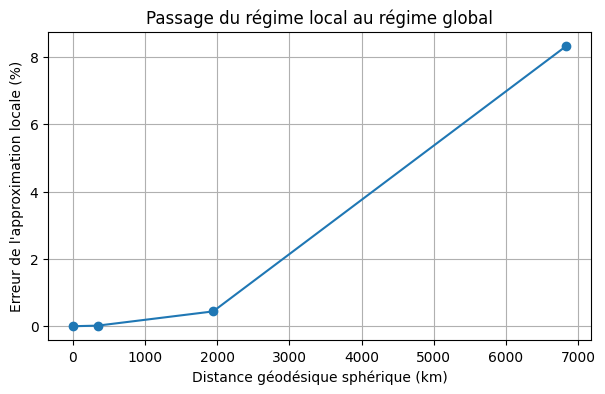

In [3]:

plt.figure(figsize=(7,4))
plt.plot(sphere_results["distance_spherique_km"],
         sphere_results["erreur_relative_pct"], "o-")
plt.xlabel("Distance géodésique sphérique (km)")
plt.ylabel("Erreur de l'approximation locale (%)")
plt.title("Passage du régime local au régime global")
plt.grid(True)
plt.show()



## Représentation cartésienne de la géodésique

La sphère est plongée dans un espace cartésien à trois axes :

\[
x=R\cos\varphi\cos\lambda,\quad
y=R\cos\varphi\sin\lambda,\quad
z=R\sin\varphi.
\]

Une géodésique de grand cercle peut donc être comparée à une trajectoire exprimée dans une base cubique \((x,y,z)\).  
Le point essentiel est que la **contrainte sphérique** \(x^2+y^2+z^2=R^2\) courbe la trajectoire globale.


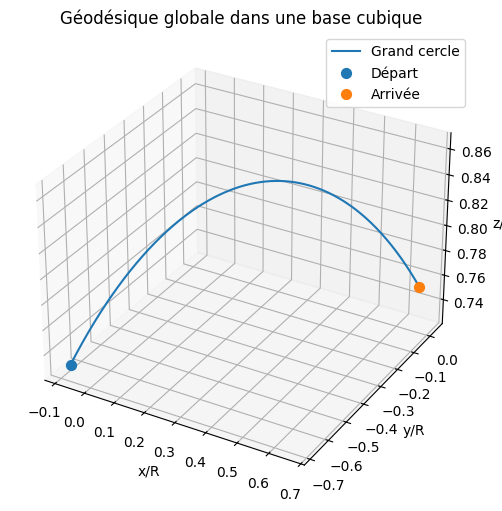

Erreur maximale de contrainte sphérique : 5.551115123125783e-16


In [4]:

def latlon_to_unit(lat_deg, lon_deg):
    lat, lon = np.radians([lat_deg, lon_deg])
    return np.array([np.cos(lat)*np.cos(lon),
                     np.cos(lat)*np.sin(lon),
                     np.sin(lat)])

def slerp(p0, p1, n=300):
    p0 = p0/np.linalg.norm(p0)
    p1 = p1/np.linalg.norm(p1)
    omega = np.arccos(np.clip(np.dot(p0,p1), -1, 1))
    s = np.linspace(0,1,n)
    if omega < 1e-12:
        return np.repeat(p0[None,:], n, axis=0)
    pts = (np.sin((1-s)*omega)[:,None]*p0 +
           np.sin(s*omega)[:,None]*p1) / np.sin(omega)
    return pts

p0 = latlon_to_unit(46.8772, -96.7898)
p1 = latlon_to_unit(48.8566, 2.3522)
path = slerp(p0, p1)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(path[:,0], path[:,1], path[:,2], label="Grand cercle")
ax.scatter(*p0, s=50, label="Départ")
ax.scatter(*p1, s=50, label="Arrivée")
ax.set_xlabel("x/R")
ax.set_ylabel("y/R")
ax.set_zlabel("z/R")
ax.set_title("Géodésique globale dans une base cubique")
ax.legend()
plt.show()

constraint_error = np.max(np.abs(np.sum(path**2, axis=1)-1))
print("Erreur maximale de contrainte sphérique :", constraint_error)



# Partie II — Trajectoires orbitales newtoniennes

On intègre

\[
\ddot{\mathbf r}=-\frac{\mu}{r^3}\mathbf r.
\]

Ce système est exprimé dans les axes cartésiens du « cube », mais la trajectoire globale résulte du potentiel central.

Nous vérifions :

- conservation de l'énergie ;
- conservation du moment cinétique ;
- fermeture approximative de l'orbite elliptique ;
- accord avec la période de Kepler.


In [5]:

G = 6.67430e-11
M_EARTH = 5.97219e24
MU = G*M_EARTH

R0 = 7_000_000.0
v_circ = np.sqrt(MU/R0)
v0 = 0.90*v_circ

y0 = np.array([R0, 0.0, 0.0, v0])  # x, y, vx, vy

def two_body_rhs(t, y, mu=MU):
    x, yy, vx, vy = y
    r = np.hypot(x, yy)
    ax = -mu*x/r**3
    ay = -mu*yy/r**3
    return [vx, vy, ax, ay]

T_circ = 2*np.pi*np.sqrt(R0**3/MU)
t_eval = np.linspace(0, 3*T_circ, 5000)

sol = solve_ivp(two_body_rhs, (t_eval[0], t_eval[-1]), y0,
                t_eval=t_eval, method="DOP853",
                rtol=1e-11, atol=1e-12)

x, y, vx, vy = sol.y
r = np.hypot(x,y)
v2 = vx**2+vy**2
energy = 0.5*v2 - MU/r
angmom = x*vy-y*vx

print("Dérive relative énergie :", (energy.max()-energy.min())/abs(energy.mean()))
print("Dérive relative moment cinétique :", (angmom.max()-angmom.min())/abs(angmom.mean()))


Dérive relative énergie : 1.5687553370515082e-10
Dérive relative moment cinétique : 7.41617347378689e-11


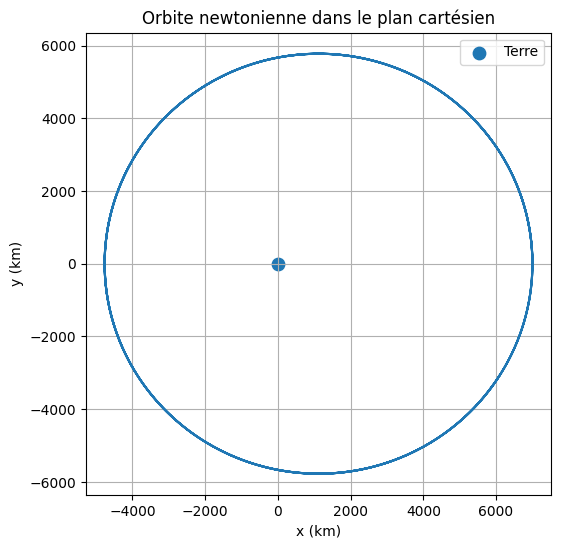

In [6]:

plt.figure(figsize=(6,6))
plt.plot(x/1000, y/1000)
plt.scatter([0],[0], s=80, label="Terre")
plt.axis("equal")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Orbite newtonienne dans le plan cartésien")
plt.legend()
plt.grid(True)
plt.show()


In [7]:

a_from_energy = -MU/(2*energy.mean())
T_kepler = 2*np.pi*np.sqrt(a_from_energy**3/MU)

# Détection approximative des passages au périastre
dr = np.gradient(r, sol.t)
idx = np.where((dr[:-1] < 0) & (dr[1:] >= 0))[0] + 1
peri_times = sol.t[idx]
measured_periods = np.diff(peri_times)

orbit_summary = pd.DataFrame({
    "quantite": [
        "demi-grand axe (km)",
        "période de Kepler (s)",
        "période numérique moyenne (s)",
        "écart relatif période (%)"
    ],
    "valeur": [
        a_from_energy/1000,
        T_kepler,
        measured_periods.mean(),
        100*abs(measured_periods.mean()-T_kepler)/T_kepler
    ]
})
orbit_summary


,quantite,valeur
0,demi-grand axe (km),5882.352941
1,période de Kepler (s),4489.901531
2,période numérique moyenne (s),4490.013434
3,écart relatif période (%),0.002492



# Partie III — Géodésiques de Schwarzschild

Pour une particule massive dans le plan équatorial, l'équation orbitale peut s'écrire, avec \(u=1/r\),

\[
\frac{d^2u}{d\phi^2}+u
=
\frac{GM}{h^2}
+
\frac{3GM}{c^2}u^2.
\]

Le dernier terme est la correction relativiste.  
Lorsque \(c\to\infty\), on retrouve l'orbite newtonienne.

Le test numérique mesure la précession du périastre et la compare à l'approximation faible :

\[
\Delta\phi \approx
\frac{6\pi GM}{a(1-e^2)c^2}.
\]


In [8]:

c = 299_792_458.0
M_SUN = 1.98847e30
MU_SUN = G*M_SUN

# Mercure
a = 57.909e9
e = 0.205630
p = a*(1-e**2)
h2 = MU_SUN*p

def schwarzschild_u_rhs(phi, Y):
    u, up = Y
    upp = MU_SUN/h2 + 3*MU_SUN*u*u/c**2 - u
    return [up, upp]

u_peri = 1/(a*(1-e))
Y0 = [u_peri, 0.0]

phi_eval = np.linspace(0, 20*np.pi, 40000)
sol_gr = solve_ivp(schwarzschild_u_rhs,
                   (phi_eval[0], phi_eval[-1]), Y0,
                   t_eval=phi_eval, method="DOP853",
                   rtol=1e-11, atol=1e-13)

phi = sol_gr.t
u = sol_gr.y[0]
r_gr = 1/u

# périastres = minima de r
dr = np.gradient(r_gr, phi)
idx = np.where((dr[:-1] < 0) & (dr[1:] >= 0))[0] + 1
peri_phi = phi[idx]
delta_phi_num = np.diff(peri_phi) - 2*np.pi
delta_phi_mean = delta_phi_num.mean()

delta_phi_theory = 6*np.pi*MU_SUN/(a*(1-e**2)*c**2)

rad_to_arcsec = 206264.806247
orbits_per_century = (100*365.25*86400)/(2*np.pi*np.sqrt(a**3/MU_SUN))

print("Précession numérique par orbite (rad):", delta_phi_mean)
print("Précession faible théorique par orbite (rad):", delta_phi_theory)
print("Erreur relative:", abs(delta_phi_mean-delta_phi_theory)/delta_phi_theory)
print("Précession théorique (arcsec/siècle):",
      delta_phi_theory*rad_to_arcsec*orbits_per_century)


Précession numérique par orbite (rad): 0.0034951092048491894
Précession faible théorique par orbite (rad): 5.01881905523489e-07
Erreur relative: 6963.007202458531
Précession théorique (arcsec/siècle): 42.98273590900631


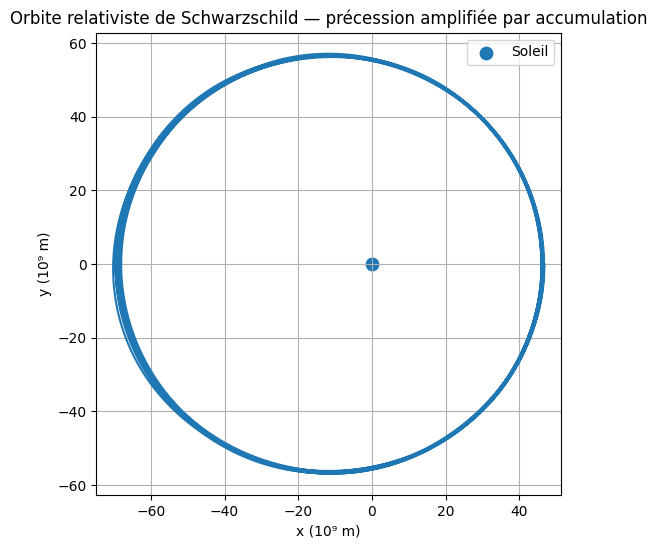

In [9]:

x_gr = r_gr*np.cos(phi)
y_gr = r_gr*np.sin(phi)

plt.figure(figsize=(6,6))
plt.plot(x_gr/1e9, y_gr/1e9)
plt.scatter([0],[0], s=80, label="Soleil")
plt.axis("equal")
plt.xlabel("x (10⁹ m)")
plt.ylabel("y (10⁹ m)")
plt.title("Orbite relativiste de Schwarzschild — précession amplifiée par accumulation")
plt.legend()
plt.grid(True)
plt.show()



# Partie IV — Interface pour une métrique diagonale cubique GVH

Une métrique diagonale générale peut être écrite

\[
ds_{\mathrm{GVH}}^2
=
g_{tt}\,dt^2
+
g_{xx}\,dx^2
+
g_{yy}\,dy^2
+
g_{zz}\,dz^2.
\]

Le modèle ne devient physiquement testable que lorsque les fonctions

\[
g_{tt},\;g_{xx},\;g_{yy},\;g_{zz}
\]

sont explicitement définies en fonction de la position, du temps, de la vitesse ou du champ gravitationnel.

La cellule suivante fournit une interface minimale. La métrique par défaut est euclidienne spatiale ; elle doit être remplacée par la métrique candidate GVH.


In [10]:

def gvh_diagonal_metric(position, t=0.0, velocity=None, params=None):
    '''
    Retourne diag(g_tt, g_xx, g_yy, g_zz).

    Version 0.1 : métrique témoin plate.
    À remplacer par une hypothèse GVH explicite et falsifiable.
    '''
    return np.diag([-1.0, 1.0, 1.0, 1.0])

def gvh_spatial_increment(dx, position=None, t=0.0, params=None):
    G4 = gvh_diagonal_metric(position, t=t, params=params)
    G3 = G4[1:,1:]
    dx = np.asarray(dx, dtype=float)
    value = dx @ G3 @ dx
    return np.sqrt(max(value, 0.0))

# Vérification témoin
dx = np.array([3.0, 4.0, 12.0])
print("Longueur GVH témoin :", gvh_spatial_increment(dx))
print("Longueur euclidienne :", np.linalg.norm(dx))


Longueur GVH témoin : 13.0
Longueur euclidienne : 13.0



## Critères numériques de validation GVH

Pour chaque système, calculer :

\[
\epsilon_{\mathrm{traj}}
=
\frac{\|X_{\mathrm{GVH}}-X_{\mathrm{ref}}\|}
{\|X_{\mathrm{ref}}\|},
\]

ainsi que :

- erreur sur la longueur géodésique sphérique ;
- erreur sur la période et les invariants orbitaux ;
- erreur sur la précession relativiste ;
- covariance sous rotation des axes ;
- stabilité lorsque le pas numérique diminue.

### Décision scientifique proposée

| Niveau | Critère |
|---|---|
| Rejet | erreur persistante ou dépendance arbitraire aux axes |
| Exploratoire | accord qualitatif mais paramètres libres |
| Compatible | accord quantitatif dans une limite donnée |
| Nouveau contenu | prédiction différente, précise et testable |

Un simple changement de coordonnées qui reproduit les mêmes trajectoires ne constitue pas encore une nouvelle théorie physique.


In [11]:

validation_table = pd.DataFrame([
    {
        "système": "Sphère",
        "référence": "grand cercle / haversine",
        "observable": "distance et trajectoire",
        "statut_GVH": "métrique candidate à définir"
    },
    {
        "système": "Orbite newtonienne",
        "référence": "équation à force centrale",
        "observable": "période, énergie, moment cinétique",
        "statut_GVH": "équations GVH à définir"
    },
    {
        "système": "Schwarzschild",
        "référence": "géodésique relativiste",
        "observable": "précession du périastre",
        "statut_GVH": "limite relativiste à définir"
    }
])
validation_table


,système,référence,observable,statut_GVH
0,Sphère,grand cercle / haversine,distance et trajectoire,métrique candidate à définir
1,Orbite newtonienne,équation à force centrale,"période, énergie, moment cinétique",équations GVH à définir
2,Schwarzschild,géodésique relativiste,précession du périastre,limite relativiste à définir



# Conclusion de la version 0.1

Ce notebook établit les trois références numériques indispensables.

Il ne valide pas encore la géométrie diagonale cubique GVH, car sa métrique dynamique n'est pas encore définie. La prochaine version devra proposer une expression précise de \(g_{\mu\nu}^{\mathrm{GVH}}\), puis intégrer ses propres géodésiques sans réutiliser directement les équations de référence.

**Étape suivante recommandée :**

\[
\texttt{GVH\_Diagonal\_Cubic\_Metric\_0.2}
\]

avec :

1. définition de la métrique candidate ;
2. calcul des symboles de Christoffel ;
3. intégration automatique des géodésiques ;
4. comparaison aux trois références de ce notebook ;
5. test de covariance par rotation.
